In [1]:
import sys
sys.path.insert(0, '/users/framunno/projects/ionosphere_diffusion')

from src.data.dataset import get_sequence_data_objects_iterable
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Same params as training
CSV_PATH = '/users/framunno/data/ionosphere/l1_to_map_matched_2020_2025.csv'
SEQUENCE_LENGTH = 36
NORM_TYPE = 'absolute_max'

results = {}

for split in ['valid']: #['train', 'valid']:
    ds, _, _ = get_sequence_data_objects_iterable(
        csv_path=CSV_PATH,
        batch_size=1,
        num_data_workers=0,
        split=split,
        seed=42,
        sequence_length=SEQUENCE_LENGTH,
        normalization_type=NORM_TYPE,
        use_l1_conditions=True,
        min_center_distance=30,
        cartesian_transform=True,
        output_size=128,
        only_complete_sequences=True,
        activity_filter=None,
    )
    ts = ds.all_timestamps
    year_month = Counter()
    year_only  = Counter()
    for cidx in ds.sequences:
        t = ts[cidx]
        year_month[f'{t.year}-{t.month:02d}'] += 1
        year_only[t.year] += 1
    results[split] = {'year_month': year_month, 'year_only': year_only, 'n': len(ds.sequences)}
    print(f'{split}: {len(ds.sequences)} sequences')
    print('  Years:', dict(sorted(year_only.items())))

Building L1 conditions cache for valid split...
Cached L1 conditions for 1370626 files

COMPUTING EPSILON THRESHOLDS FOR VALID SPLIT
Computed from 12650 sequences:
  Mean:   0.5 GW
  Median: 0.2 GW
  Min:    0.0 GW
  Max:    81.7 GW

Activity thresholds:
  Low (0):    epsilon < 0.1 GW
  Medium (1): 0.1 GW ≤ epsilon < 0.5 GW
  High (2):   epsilon ≥ 0.5 GW

Filtered sequences for valid: 12650 -> 7786 (61.5% complete)
IonoSequenceIterableDataset [valid]: 7786 sequences
  GPU rank: 0/1, Shuffle: True
valid: 7786 sequences
  Years: {2020: 4793, 2024: 312, 2025: 2681}


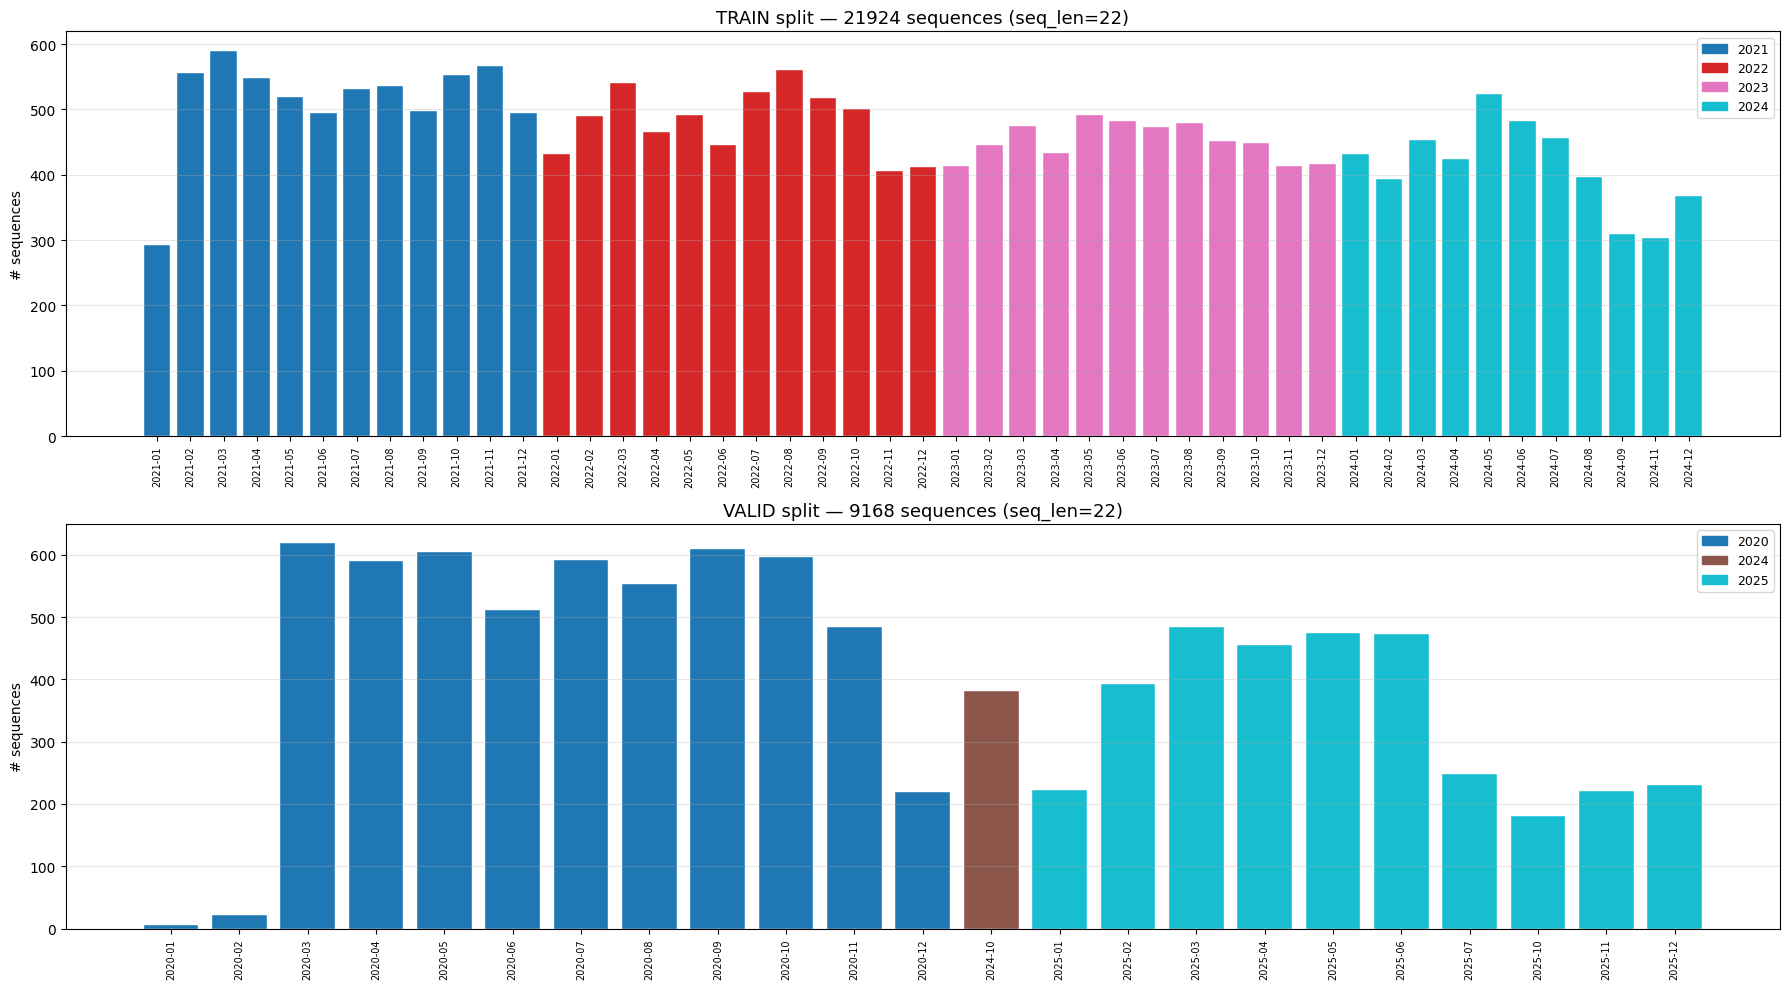

In [5]:
from IPython.display import display, Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def show(fig, name):
    path = f'/tmp/{name}'
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    display(Image(path))

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for ax, split in zip(axes, ['train', 'valid']):
    ym = results[split]['year_month']
    keys = sorted(ym.keys())
    vals = [ym[k] for k in keys]

    years = sorted(set(k[:4] for k in keys))
    cmap = plt.cm.get_cmap('tab10', len(years))
    colors = [cmap(years.index(k[:4])) for k in keys]

    ax.bar(range(len(keys)), vals, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=90, fontsize=7)
    ax.set_title(f'{split.upper()} split — {results[split]["n"]} sequences (seq_len={SEQUENCE_LENGTH})', fontsize=13)
    ax.set_ylabel('# sequences')
    ax.grid(axis='y', alpha=0.3)

    handles = [Patch(color=cmap(i), label=yr) for i, yr in enumerate(years)]
    ax.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout()
show(fig, 'dataset_years.png')

In [6]:
# Summary table
print('=== YEAR TOTALS ===')
for split in ['train', 'valid']:
    print(f'\n{split.upper()}:')
    for yr, cnt in sorted(results[split]['year_only'].items()):
        print(f'  {yr}: {cnt:5d} sequences')
    print(f'  TOTAL: {results[split]["n"]}')

=== YEAR TOTALS ===

TRAIN:
  2021:  6175 sequences
  2022:  5787 sequences
  2023:  5423 sequences
  2024:  4539 sequences
  TOTAL: 21924

VALID:
  2020:  5404 sequences
  2024:   382 sequences
  2025:  3382 sequences
  TOTAL: 9168


In [18]:
import os
MAP_DIR = '/capstor/scratch/cscs/framunno/ionosphere_data/all_maps/'

def check_year(year, seq_len=36, max_check=20):
    seqs_year = [s for s in ds.sequences if ts[s].year == year]
    print(f'{year}: {len(seqs_year)} sequences in dataset')
    complete = 0
    for cidx in seqs_year:#[:max_check]:
        start = cidx - seq_len // 2
        missing = sum(1 for fi in range(start, start + seq_len)
                    if not os.path.exists(MAP_DIR + ds.all_files[fi]))
        if missing == 0:
            complete += 1
    print(f'  Complete (first {max_check}): {complete}/{max_check}')

check_year(2024, seq_len=22)
#check_year(2020, seq_len=36)

2024: 312 sequences in dataset
  Complete (first 20): 0/20
